In [ ]:
# ============================================================
# 0. SETUP: IMPORTS, DEVICE, SEED, DRIVE MOUNT (COLAB)
# ============================================================

import os
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt
from collections import Counter
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

In [ ]:
# ---- Mount Google Drive ----
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ============================================================
# 1. PATHS & GLOBAL SETTINGS
# ============================================================


DATA_ROOT = "/content/drive/MyDrive/KaggleDatasets/CASIA2"

# ----------------------------------------------------------------

AU_DIR   = os.path.join(DATA_ROOT, "Au")
TP_DIR   = os.path.join(DATA_ROOT, "Tp")
MASK_DIR = os.path.join(DATA_ROOT, "CASIA 2 Groundtruth")

print("DATA_ROOT:", DATA_ROOT)
print("AU_DIR exists?  ", os.path.isdir(AU_DIR))
print("TP_DIR exists?  ", os.path.isdir(TP_DIR))
print("MASK_DIR exists?", os.path.isdir(MASK_DIR))

# Hyperparameters
IMG_SIZE       = 224          # classification
SEG_IMG_SIZE   = 256          # segmentation
BATCH_SIZE     = 16
BATCH_SIZE_SEG = 8

NUM_EPOCHS_CLS = 20           # ResNet50 epochs
NUM_EPOCHS_SEG = 30          # U-Net epochs

NUM_WORKERS    = 0
USE_PIN_MEMORY = True if torch.cuda.is_available() else False

SEED = 42
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if device.type == "cuda":
    torch.cuda.manual_seed_all(SEED)

# where to save best models
BEST_RESNET_PATH = os.path.join(DATA_ROOT, "best_resnet50_spatial.pth")
BEST_UNET_PATH   = os.path.join(DATA_ROOT, "best_unet_casia2.pth")

DATA_ROOT: /content/drive/MyDrive/KaggleDatasets/CASIA2
AU_DIR exists?   True
TP_DIR exists?   True
MASK_DIR exists? True
Using device: cuda


In [ ]:
# ============================================================
# 2. CLASSIFICATION DATA: COLLECT PATHS (Au=Real, Tp=Forged)
# ============================================================

def collect_image_paths(au_dir, tp_dir,
                        exts=(".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")):
    au_paths, tp_paths = [], []
    for root, _, files in os.walk(au_dir):
        for f in files:
            if f.lower().endswith(exts):
                au_paths.append(os.path.join(root, f))

    for root, _, files in os.walk(tp_dir):
        for f in files:
            if f.lower().endswith(exts):
                tp_paths.append(os.path.join(root, f))

    paths = au_paths + tp_paths
    labels = [0]*len(au_paths) + [1]*len(tp_paths)   # 0 = Real, 1 = Forged
    return np.array(paths), np.array(labels, dtype=np.int64)

all_paths, all_labels = collect_image_paths(AU_DIR, TP_DIR)
print("Total images:", len(all_paths))
print("Real:", (all_labels == 0).sum(), " Forged:", (all_labels == 1).sum())

if len(all_paths) == 0:
    raise RuntimeError(
        "No images found!\n"
        f"Check AU_DIR={AU_DIR} and TP_DIR={TP_DIR}.\n"
        "They must contain Au and Tp images."
    )

Total images: 13208
Real: 7491  Forged: 5717


In [ ]:
# ============================================================
# 3. TRAIN/VAL/TEST SPLIT (CLASSIFICATION)
# ============================================================

X_train_paths, X_tmp_paths, y_train, y_tmp = train_test_split(
    all_paths, all_labels,
    test_size=0.3, random_state=SEED, stratify=all_labels
)

X_val_paths, X_test_paths, y_val, y_test = train_test_split(
    X_tmp_paths, y_tmp,
    test_size=0.5, random_state=SEED, stratify=y_tmp
)

print("Train:", len(X_train_paths),
      "Val:", len(X_val_paths),
      "Test:", len(X_test_paths))


Train: 9245 Val: 1981 Test: 1982


In [ ]:
# ============================================================
# 4. DATASET & DATALOADERS (CLASSIFICATION, ResNet50)
# ============================================================

class ForgeryDataset(Dataset):
    def __init__(self, img_paths, labels, train=True, img_size=IMG_SIZE):
        self.img_paths = list(img_paths)
        self.labels    = list(labels)
        self.train     = train
        self.img_size  = img_size

        if train:
            self.transform = transforms.Compose([
                transforms.ToPILImage(),
                transforms.RandomResizedCrop(
                  IMG_SIZE,
                  scale=(0.9, 1.0),
                  ratio=(0.9, 1.1)
                ),
                transforms.RandomHorizontalFlip(0.5),
                transforms.RandomRotation(5),
                transforms.ColorJitter(brightness=0.1, contrast=0.1),
                transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.5)),
                transforms.Resize((img_size, img_size)),
                transforms.ToTensor(),
                transforms.Normalize(
                    [0.485, 0.456, 0.406],
                    [0.229, 0.224, 0.225]
                )
            ])
        else:
            self.transform = transforms.Compose([
                transforms.ToPILImage(),
                transforms.Resize((img_size, img_size)),
                transforms.ToTensor(),
                transforms.Normalize(
                    [0.485, 0.456, 0.406],
                    [0.229, 0.224, 0.225]
                )
            ])

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        path  = self.img_paths[idx]
        label = self.labels[idx]

        img_bgr = cv2.imread(path, cv2.IMREAD_COLOR)
        if img_bgr is None:
            img_bgr = np.zeros((self.img_size, self.img_size, 3), dtype=np.uint8)
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        img_tensor   = self.transform(img_rgb)
        label_tensor = torch.tensor(label, dtype=torch.float32)   # for BCEWithLogits
        return img_tensor, label_tensor

train_dataset = ForgeryDataset(X_train_paths, y_train, train=True)
val_dataset   = ForgeryDataset(X_val_paths,   y_val,   train=False)
test_dataset  = ForgeryDataset(X_test_paths,  y_test,  train=False)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=USE_PIN_MEMORY
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=USE_PIN_MEMORY
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=USE_PIN_MEMORY
)


In [ ]:
# ============================================================
# 5. RESNET50 MODEL (IMAGE-ONLY)
# ============================================================

def get_resnet50_backbone():
    res = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    feat_dim = res.fc.in_features
    res.fc = nn.Identity()
    return res, feat_dim

class SpatialResNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone, feat_dim = get_resnet50_backbone()
        self.classifier = nn.Sequential(
            nn.Linear(feat_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 1)
        )

    def forward(self, x_img):
        feats = self.backbone(x_img)
        logit = self.classifier(feats).squeeze(1)   # [B]
        return logit

resnet_model = SpatialResNet().to(device)
print(resnet_model)

SpatialResNet(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
   

In [ ]:
# ============================================================
# 6. TRAINING UTILS (LOSS, TRAIN/EVAL, THR TUNING)
# ============================================================

def train_one_epoch_cls(model, loader, optimizer, criterion, phase_name="Train"):
    model.train()
    total_loss = 0.0
    all_probs, all_targets = [], []

    pbar = tqdm(loader, desc=f"{phase_name} (cls)", leave=False)
    for imgs, labels in pbar:
        imgs   = imgs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        logits = model(imgs)           # [B]
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)

        probs = torch.sigmoid(logits).detach().cpu().numpy()
        all_probs.append(probs)
        all_targets.append(labels.detach().cpu().numpy())

        pbar.set_postfix({"loss": f"{loss.item():.4f}"})

    total_loss /= len(loader.dataset)
    all_probs   = np.concatenate(all_probs)
    all_targets = np.concatenate(all_targets)

    preds = (all_probs >= 0.5).astype(int)
    acc  = accuracy_score(all_targets, preds)
    try:
        auc = roc_auc_score(all_targets, all_probs)
    except ValueError:
        auc = np.nan

    return total_loss, acc, auc

@torch.no_grad()
def evaluate_cls(model, loader, criterion, phase_name="Val"):
    model.eval()
    total_loss = 0.0
    all_probs, all_targets = [], []

    pbar = tqdm(loader, desc=f"{phase_name} (cls)", leave=False)
    for imgs, labels in pbar:
        imgs   = imgs.to(device)
        labels = labels.to(device)

        logits = model(imgs)
        loss   = criterion(logits, labels)

        total_loss += loss.item() * imgs.size(0)
        probs = torch.sigmoid(logits).cpu().numpy()
        all_probs.append(probs)
        all_targets.append(labels.cpu().numpy())

        pbar.set_postfix({"val_loss": f"{loss.item():.4f}"})

    total_loss /= len(loader.dataset)
    all_probs   = np.concatenate(all_probs)
    all_targets = np.concatenate(all_targets)

    preds = (all_probs >= 0.5).astype(int)
    acc  = accuracy_score(all_targets, preds)
    try:
        auc = roc_auc_score(all_targets, all_probs)
    except ValueError:
        auc = np.nan

    return total_loss, acc, auc, all_probs, all_targets

def tune_threshold(probs, targets):
    best_thr, best_acc = 0.5, 0.0
    for thr in np.linspace(0.2, 0.8, 61):
        preds = (probs >= thr).astype(int)
        acc = accuracy_score(targets, preds)
        if acc > best_acc:
            best_acc, best_thr = acc, thr
    return best_thr, best_acc

In [ ]:
#CLASS WEIGHTS (pos_weight FOR FORGED CLASS)
class_counts = Counter(y_train)
n_real   = class_counts[0]
n_forged = class_counts[1]
pos_weight_value = n_real / max(1, n_forged)   # forged = 1

print(f"Train class counts -> Real: {n_real}, Forged: {n_forged}, pos_weight={pos_weight_value:.3f}")

pos_w_tensor = torch.tensor(pos_weight_value, dtype=torch.float32, device=device)

Train class counts -> Real: 5243, Forged: 4002, pos_weight=1.310


=== Training ResNet50 Classifier ===


Train-Ep1 (cls):   0%|          | 0/578 [00:00<?, ?it/s]

Val-Ep1 (cls):   0%|          | 0/124 [00:00<?, ?it/s]

[Epoch 1/20] Train Loss: 0.5680, Acc: 0.7126, AUC: 0.7735 | Val Loss: 0.5582, Acc: 0.7097, AUC: 0.7988
✅ Saved best ResNet50 to /content/drive/MyDrive/KaggleDatasets/CASIA2/best_resnet50_spatial.pth


Train-Ep2 (cls):   0%|          | 0/578 [00:00<?, ?it/s]

...

Val-Ep19 (cls):   0%|          | 0/124 [00:00<?, ?it/s]

[Epoch 19/20] Train Loss: 0.2317, Acc: 0.8951, AUC: 0.9635 | Val Loss: 0.5125, Acc: 0.8036, AUC: 0.8608


Train-Ep20 (cls):   0%|          | 0/578 [00:00<?, ?it/s]

Val-Ep20 (cls):   0%|          | 0/124 [00:00<?, ?it/s]

[Epoch 20/20] Train Loss: 0.2247, Acc: 0.8983, AUC: 0.9648 | Val Loss: 0.5130, Acc: 0.7925, AUC: 0.8573
Best Val AUC: 0.8640617149121532


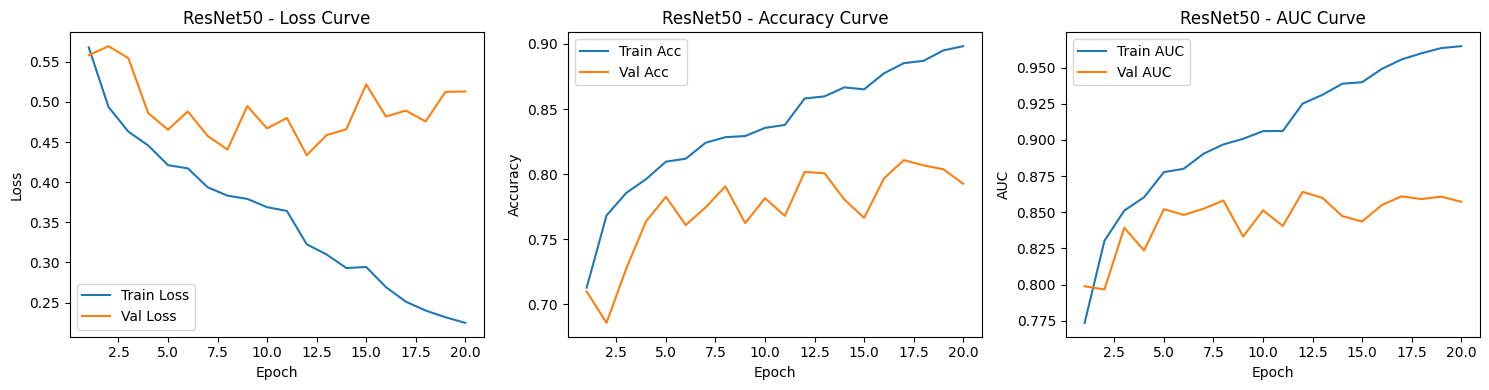

In [ ]:
# ============================================================
# 7. TRAIN RESNET50, SAVE BEST, PLOT CURVES
# ============================================================

criterion_cls = nn.BCEWithLogitsLoss()
optimizer_cls = torch.optim.Adam(resnet_model.parameters(), lr=1e-4)
scheduler_cls = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_cls, mode='min', factor=0.5, patience=2
)

best_val_auc = -np.inf
best_val_probs = best_val_targets = None

train_losses, val_losses = [], []
train_accs, val_accs     = [], []
train_aucs, val_aucs     = [], []

print("=== Training ResNet50 Classifier ===")
for epoch in range(1, NUM_EPOCHS_CLS + 1):
    tr_loss, tr_acc, tr_auc = train_one_epoch_cls(
        resnet_model, train_loader, optimizer_cls, criterion_cls,
        phase_name=f"Train-Ep{epoch}"
    )
    val_loss, val_acc, val_auc, val_probs, val_targets = evaluate_cls(
        resnet_model, val_loader, criterion_cls,
        phase_name=f"Val-Ep{epoch}"
    )
    scheduler_cls.step(val_loss)

    train_losses.append(tr_loss)
    val_losses.append(val_loss)
    train_accs.append(tr_acc)
    val_accs.append(val_acc)
    train_aucs.append(tr_auc)
    val_aucs.append(val_auc)

    print(f"[Epoch {epoch}/{NUM_EPOCHS_CLS}] "
          f"Train Loss: {tr_loss:.4f}, Acc: {tr_acc:.4f}, AUC: {tr_auc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}, AUC: {val_auc:.4f}")

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_val_probs   = val_probs.copy()
        best_val_targets = val_targets.copy()
        torch.save(resnet_model.state_dict(), BEST_RESNET_PATH)
        print(f"✅ Saved best ResNet50 to {BEST_RESNET_PATH}")

print("Best Val AUC:", best_val_auc)

# ---- Plot Loss, Accuracy, AUC Curves ----
epochs_arr = np.arange(1, len(train_losses) + 1)

plt.figure(figsize=(15,4))

# Loss
plt.subplot(1,3,1)
plt.plot(epochs_arr, train_losses, label="Train Loss")
plt.plot(epochs_arr, val_losses,   label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet50 - Loss Curve")
plt.legend()

# Accuracy
plt.subplot(1,3,2)
plt.plot(epochs_arr, train_accs, label="Train Acc")
plt.plot(epochs_arr, val_accs,   label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ResNet50 - Accuracy Curve")
plt.legend()

# AUC
plt.subplot(1,3,3)
plt.plot(epochs_arr, train_aucs, label="Train AUC")
plt.plot(epochs_arr, val_aucs,   label="Val AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.title("ResNet50 - AUC Curve")
plt.legend()

plt.tight_layout()
plt.show()

Best validation threshold: 0.430, val acc: 0.8092


Test (cls):   0%|          | 0/124 [00:00<?, ?it/s]


=== ResNet50 Test Results ===
Loss: 0.4503 AUC: 0.8602 Acc: 0.8032
              precision    recall  f1-score   support

        Real       0.89      0.74      0.81      1124
      Forged       0.72      0.88      0.79       858

    accuracy                           0.80      1982
   macro avg       0.81      0.81      0.80      1982
weighted avg       0.82      0.80      0.80      1982



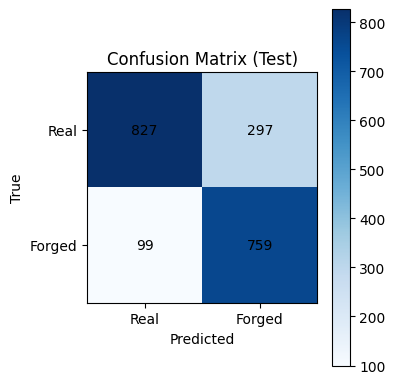

In [ ]:
# ============================================================
# 8. FINAL TEST EVALUATION + CONFUSION MATRIX
# ============================================================

# Reload best weights
resnet_model.load_state_dict(torch.load(BEST_RESNET_PATH, map_location=device))

# Tune threshold on validation
best_thr, best_val_acc = tune_threshold(best_val_probs, best_val_targets)
print(f"Best validation threshold: {best_thr:.3f}, val acc: {best_val_acc:.4f}")

# Evaluate on test set
test_loss, test_acc, test_auc, test_probs, test_targets = evaluate_cls(
    resnet_model, test_loader, criterion_cls, phase_name="Test"
)

test_preds = (test_probs >= best_thr).astype(int)
print("\n=== ResNet50 Test Results ===")
print("Loss:", round(test_loss,4), "AUC:", round(test_auc,4), "Acc:", round(test_acc,4))
print(classification_report(test_targets, test_preds, target_names=["Real","Forged"]))

cm = confusion_matrix(test_targets, test_preds)
plt.figure(figsize=(4,4))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix (Test)")
plt.colorbar()
plt.xticks([0,1], ["Real","Forged"])
plt.yticks([0,1], ["Real","Forged"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i,j], ha="center", va="center", color="black")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# GRAD-CAM FOR RESNET50 (IMAGE-ONLY)
# ============================================================

# -------- Inverse normalization (ImageNet stats) --------
inv_mean = np.array([0.485, 0.456, 0.406])
inv_std  = np.array([0.229, 0.224, 0.225])

def denormalize_image(img_tensor):
    """
    img_tensor: [3, H, W] normalized with ImageNet stats.
    returns: [H, W, 3] float in [0,1]
    """
    img = img_tensor.permute(1, 2, 0).cpu().numpy()
    img = img * inv_std + inv_mean
    img = np.clip(img, 0, 1)
    return img

class ResNetGradCAM:
    def __init__(self, model):
        """
        Grad-CAM for your SpatialResNet (binary classifier).
        Uses the last ResNet conv block: backbone.layer4[-1]
        """
        self.model = model
        self.model.eval()

        # target layer: last block of layer4
        self.target_layer = self.model.backbone.layer4[-1]

        self.activations = None
        self.gradients   = None

        self.fwd_handle = self.target_layer.register_forward_hook(self._forward_hook)
        self.bwd_handle = self.target_layer.register_full_backward_hook(self._backward_hook)

    def _forward_hook(self, module, inp, out):
        # out: [B, C, H, W]
        self.activations = out

    def _backward_hook(self, module, grad_in, grad_out):
        # grad_out[0]: [B, C, H, W]
        self.gradients = grad_out[0]

    def generate(self, img_tensor, target_class=None):
        """
        img_tensor: [1,3,H,W] on device

        Returns:
          cam        : [H,W] numpy in [0,1]
          pred_class : 0=Real, 1=Forged
          probs      : np.array([p_real, p_forged])
        """
        self.model.eval()
        self.model.zero_grad()

        # Forward: binary logit
        output = self.model(img_tensor)       # [1] or [1,1]
        if output.ndim == 2:
            logit = output[0, 0]
        else:
            logit = output[0]

        # Probabilities for interpretation
        p_forged = torch.sigmoid(logit).item()
        p_real   = 1.0 - p_forged
        probs_np = np.array([p_real, p_forged], dtype=np.float32)
        pred_class = 1 if p_forged >= 0.5 else 0

        # Backprop w.r.t. this logit
        self.model.zero_grad()
        logit.backward(retain_graph=False)

        # Activations & gradients for this sample
        act  = self.activations[0]  # [C,H,W]
        grad = self.gradients[0]    # [C,H,W]

        # Channel-wise weights: global-average-grad over spatial dims
        weights = grad.mean(dim=(1, 2))  # [C]

        cam = torch.zeros_like(act[0])
        for c, w in enumerate(weights):
            cam += w * act[c]

        cam = torch.relu(cam)
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)

        return cam.detach().cpu().numpy(), pred_class, probs_np

    def release(self):
        self.fwd_handle.remove()
        self.bwd_handle.remove()


def overlay_heatmap(img_uint8, cam):
    """
    img_uint8: RGB uint8 image [H,W,3]
    cam      : [H,W] in [0,1]
    Returns: overlay (RGB uint8), heatmap (RGB uint8), cam_resized
    """
    h, w, _ = img_uint8.shape
    cam_resized = cv2.resize(cam, (w, h))
    cam_uint8   = np.uint8(255 * cam_resized)

    heatmap_bgr = cv2.applyColorMap(cam_uint8, cv2.COLORMAP_JET)
    heatmap_rgb = cv2.cvtColor(heatmap_bgr, cv2.COLOR_BGR2RGB)

    overlay = cv2.addWeighted(img_uint8, 0.6, heatmap_rgb, 0.4, 0)
    return overlay, heatmap_rgb, cam_resized


# ============================================================
# VISUALIZE GRAD-CAM ON A FEW TEST IMAGES
# ============================================================


resnet_model.eval()
gradcam = ResNetGradCAM(resnet_model)

max_images_to_plot = 6
idxs = np.random.choice(len(test_dataset),
                        size=min(max_images_to_plot, len(test_dataset)),
                        replace=False)

for idx in idxs:

    img_tensor, label = test_dataset[idx]

    # Denormalize for display
    img_np = denormalize_image(img_tensor)         # [H,W,3] float [0,1]
    img_uint8 = (img_np * 255).astype(np.uint8)    # RGB uint8

    # Prepare batch for model
    img_batch = img_tensor.unsqueeze(0).to(device)

    # Grad-CAM
    cam, pred_class, probs = gradcam.generate(img_batch)
    overlay, heatmap_rgb, cam_resized = overlay_heatmap(img_uint8, cam)

    pred_name = "Real"   if pred_class == 0 else "Forged"
    true_name = "Real"   if int(label) == 0 else "Forged"
    confidence = probs[pred_class] * 100.0

    plt.figure(figsize=(14, 4))

    plt.subplot(1, 3, 1)
    plt.title(f"Original\n(True: {true_name})")
    plt.imshow(img_uint8)
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.title("Grad-CAM Heatmap")
    plt.imshow(heatmap_rgb)
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.title(f"Overlay\n(Pred: {pred_name}, {confidence:.1f}%)")
    plt.imshow(overlay)
    plt.axis("off")

    plt.tight_layout()
    plt.show()




Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# ============================================================
# XAI WITH GRAD-CAM: ANALYZE TPs, FPs, FNs ON TEST SET
# ============================================================


# 1) Load best ResNet weights (safety)
resnet_model.load_state_dict(torch.load(BEST_RESNET_PATH, map_location=device))
resnet_model.eval()

# 2) Use best threshold from validation
best_thr, best_val_acc = tune_threshold(best_val_probs, best_val_targets)
print(f"[XAI] Using best validation threshold: {best_thr:.3f} (val acc={best_val_acc:.4f})")


@torch.no_grad()
def collect_test_predictions(model, loader, thr=0.5):
    """
    Run model on test_loader and collect:
      - probabilities (p_forged)
      - true labels
      - predicted labels (using thr)
      - dataset indices (0..len(test_dataset)-1)
    Assumes test_loader was created with shuffle=False.
    """
    model.eval()
    all_probs, all_labels, all_preds = [], [], []
    all_indices = []

    idx_counter = 0
    for imgs, labels in loader:
        imgs   = imgs.to(device)
        labels = labels.to(device)
        bsz    = imgs.size(0)

        logits = model(imgs)                       # [B]
        probs  = torch.sigmoid(logits).cpu().numpy().reshape(-1)  # p_forged
        labels_np = labels.cpu().numpy().astype(int)

        preds  = (probs >= thr).astype(int)

        all_probs.append(probs)
        all_labels.append(labels_np)
        all_preds.append(preds)

        batch_indices = np.arange(idx_counter, idx_counter + bsz)
        all_indices.append(batch_indices)
        idx_counter += bsz

    all_probs   = np.concatenate(all_probs)
    all_labels  = np.concatenate(all_labels)
    all_preds   = np.concatenate(all_preds)
    all_indices = np.concatenate(all_indices)

    return all_probs, all_labels, all_preds, all_indices


# 3) Collect predictions on test set
test_probs, test_labels, test_preds, test_indices = collect_test_predictions(
    resnet_model, test_loader, thr=best_thr
)

print("\n[XAI] Test confusion matrix (using best threshold):")
cm = confusion_matrix(test_labels, test_preds, labels=[0,1])
print("Rows: True [Real(0), Forged(1)], Cols: Pred [Real(0), Forged(1)]")
print(cm)

# Build masks for groups
is_real   = (test_labels == 0)
is_forged = (test_labels == 1)

tp_real_idx   = test_indices[(test_preds == 0) & is_real]    # TN for Real class
tp_forged_idx = test_indices[(test_preds == 1) & is_forged]  # TP for Forged class
fp_idx        = test_indices[(test_preds == 1) & is_real]    # False Positive: Real -> Forged
fn_idx        = test_indices[(test_preds == 0) & is_forged]  # False Negative: Forged -> Real

print(f"\n[XAI] Group sizes:")
print(f"  True Real   (TN): {len(tp_real_idx)}")
print(f"  True Forged (TP): {len(tp_forged_idx)}")
print(f"  False Positives  : {len(fp_idx)}")
print(f"  False Negatives  : {len(fn_idx)}")

# 4) Grad-CAM visualizer for a group of indices
def show_gradcam_group(indices, group_name, max_examples=4):
    """
    Show Grad-CAM for up to max_examples from a given group of dataset indices.
    """
    if len(indices) == 0:
        print(f"[XAI] No examples available for group: {group_name}")
        return

    # choose a subset
    if len(indices) > max_examples:
        chosen = np.random.choice(indices, size=max_examples, replace=False)
    else:
        chosen = indices

    print(f"\n[XAI] Visualizing {len(chosen)} example(s) from group: {group_name}")

    gradcam = ResNetGradCAM(resnet_model)

    for idx in chosen:
        # If your test_dataset returns (img, label):
        img_tensor, label = test_dataset[idx]
        # If it returns (img, something, label), use:
        # img_tensor, _, label = test_dataset[idx]

        img_np    = denormalize_image(img_tensor)                 # [H,W,3] in [0,1]
        img_uint8 = (img_np * 255).astype(np.uint8)

        img_batch = img_tensor.unsqueeze(0).to(device)
        cam, pred_class, probs = gradcam.generate(img_batch)
        overlay, heatmap_rgb, cam_resized = overlay_heatmap(img_uint8, cam)

        pred_name = "Real" if pred_class == 0 else "Forged"
        true_name = "Real" if int(label) == 0 else "Forged"
        confidence = probs[pred_class] * 100.0

        plt.figure(figsize=(14, 4))

        plt.suptitle(
            f"{group_name} | True: {true_name}, Pred: {pred_name} ({confidence:.1f}%)",
            fontsize=12
        )

        plt.subplot(1, 3, 1)
        plt.title("Original")
        plt.imshow(img_uint8)
        plt.axis("off")

        plt.subplot(1, 3, 2)
        plt.title("Grad-CAM Heatmap")
        plt.imshow(heatmap_rgb)
        plt.axis("off")

        plt.subplot(1, 3, 3)
        plt.title("Overlay")
        plt.imshow(overlay)
        plt.axis("off")

        plt.tight_layout()
        plt.show()

    gradcam.release()


# 5) Actually visualize for each group (this is your XAI analysis)
show_gradcam_group(tp_real_idx,   "TN: Correctly Classified Real",   max_examples=3)
show_gradcam_group(tp_forged_idx, "TP: Correctly Classified Forged", max_examples=3)
show_gradcam_group(fp_idx,        "FP: Real misclassified as Forged",max_examples=3)
show_gradcam_group(fn_idx,        "FN: Forged misclassified as Real",max_examples=3)


Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# ============================================================
# 9. SEGMENTATION (U-NET) - BUILD MASK INDEX
# ============================================================

def normalize_name(path_or_name):
    base = os.path.basename(path_or_name)
    name, _ = os.path.splitext(base)
    name = name.lower()

    suffixes = [
        "_gt", "-gt",
        "_mask", "-mask",
        "_binary", "_bin",
        "_edgemap", "-edgemap",
        "_gt0", "_gt1"
    ]
    for suf in suffixes:
        if name.endswith(suf):
            name = name[:-len(suf)]
    return name

def build_mask_index(mask_root):
    index = {}
    total_files = 0
    for root, _, files in os.walk(mask_root):
        for f in files:
            total_files += 1
            full_path = os.path.join(root, f)
            key = normalize_name(f)
            index.setdefault(key, []).append(full_path)
    print(f"Mask index built with {len(index)} normalized keys from {total_files} files.")
    return index

mask_index = build_mask_index(MASK_DIR)

def collect_segmentation_pairs(tp_dir, mask_index, max_unmatched_print=10):
    img_paths, mask_paths = [], []
    unmatched = []
    total_tp = 0

    for root, _, files in os.walk(tp_dir):
        for f in files:
            total_tp += 1
            img_path = os.path.join(root, f)
            key = normalize_name(f)

            if key in mask_index:
                img_paths.append(img_path)
                mask_paths.append(mask_index[key][0])
            else:
                unmatched.append((f, key))

    img_paths  = np.array(img_paths)
    mask_paths = np.array(mask_paths)
    print(f"Total TP images found: {total_tp}")
    print(f"Segmentation pairs found: {len(img_paths)}")
    if len(unmatched) > 0:
        print("Unmatched TP images (showing up to 10):")
        for f, k in unmatched[:max_unmatched_print]:
            print(f"  TP file: {f}  -> normalized: '{k}' (no matching mask key)")
    return img_paths, mask_paths

seg_img_paths, seg_mask_paths = collect_segmentation_pairs(TP_DIR, mask_index)

if len(seg_img_paths) == 0:
    raise RuntimeError("No segmentation pairs found. Check TP_DIR/MASK_DIR naming.")

Mask index built with 5123 normalized keys from 5123 files.
Total TP images found: 5717
Segmentation pairs found: 5562
Unmatched TP images (showing up to 10):
  TP file: Tp_S_NRN_S_N_art20067_arc20001_01873.tif  -> normalized: 'tp_s_nrn_s_n_art20067_arc20001_01873' (no matching mask key)
  TP file: Tp_S_NRN_S_N_cha10167_cha10208_12368.jpg  -> normalized: 'tp_s_nrn_s_n_cha10167_cha10208_12368' (no matching mask key)
  TP file: Tp_S_NRN_S_N_ind10103_ind10104_11552.jpg  -> normalized: 'tp_s_nrn_s_n_ind10103_ind10104_11552' (no matching mask key)
  TP file: Tp_S_NRN_S_N_ind00046_ind00046_10893.jpg  -> normalized: 'tp_s_nrn_s_n_ind00046_ind00046_10893' (no matching mask key)
  TP file: Tp_S_NRN_S_N_ind00034_art00068_00449.tif  -> normalized: 'tp_s_nrn_s_n_ind00034_art00068_00449' (no matching mask key)
  TP file: Tp_S_NRN_S_N_ind00048_ind00034_00456.tif  -> normalized: 'tp_s_nrn_s_n_ind00048_ind00034_00456' (no matching mask key)
  TP file: Tp_S_NRN_S_N_pla20017_pla20027_01927.tif  -> norma

In [ ]:
# ============================================================
# 10. TRAIN/VAL SPLIT (SEGMENTATION)
# ============================================================

seg_train_imgs, seg_val_imgs, seg_train_masks, seg_val_masks = train_test_split(
    seg_img_paths, seg_mask_paths, test_size=0.2, random_state=SEED
)
print("Seg train:", len(seg_train_imgs), "Seg val:", len(seg_val_imgs))


Seg train: 4449 Seg val: 1113


In [ ]:
# ============================================================
# 11. SEGMENTATION DATASET & DATALOADERS
# ============================================================

class SegmentationDataset(Dataset):
    def __init__(self, img_paths, mask_paths, train=True, img_size=SEG_IMG_SIZE):
        self.img_paths  = list(img_paths)
        self.mask_paths = list(mask_paths)
        self.train      = train
        self.img_size   = img_size

        self.img_tf = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize(
                [0.485, 0.456, 0.406],
                [0.229, 0.224, 0.225]
            )
        ])

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img_path  = self.img_paths[idx]
        mask_path = self.mask_paths[idx]

        img_bgr = cv2.imread(img_path, cv2.IMREAD_COLOR)
        if img_bgr is None:
            img_bgr = np.zeros((self.img_size, self.img_size, 3), dtype=np.uint8)
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        img_rgb = cv2.resize(img_rgb, (self.img_size, self.img_size),
                             interpolation=cv2.INTER_LINEAR)

        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if mask is None:
            mask = np.zeros((self.img_size, self.img_size), dtype=np.uint8)
        mask = cv2.resize(mask, (self.img_size, self.img_size),
                          interpolation=cv2.INTER_NEAREST)
        mask = (mask > 127).astype(np.float32)

        if self.train and np.random.rand() < 0.5:
            img_rgb = np.fliplr(img_rgb).copy()
            mask    = np.fliplr(mask).copy()

        img_t  = self.img_tf(img_rgb)
        mask_t = torch.from_numpy(mask).unsqueeze(0).float()
        return img_t, mask_t

seg_train_dataset = SegmentationDataset(seg_train_imgs, seg_train_masks, train=True)
seg_val_dataset   = SegmentationDataset(seg_val_imgs,   seg_val_masks,   train=False)

seg_train_loader = DataLoader(
    seg_train_dataset, batch_size=BATCH_SIZE_SEG, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=USE_PIN_MEMORY
)
seg_val_loader = DataLoader(
    seg_val_dataset, batch_size=BATCH_SIZE_SEG, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=USE_PIN_MEMORY
)


In [ ]:
# ============================================================
# 12. U-NET MODEL
# ============================================================

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.seq = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.seq(x)

class UNet(nn.Module):
    def __init__(self, in_ch=3, out_ch=1):
        super().__init__()
        self.down1 = DoubleConv(in_ch, 64)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        self.down3 = DoubleConv(128, 256)
        self.pool3 = nn.MaxPool2d(2)

        self.down4 = DoubleConv(256, 512)
        self.pool4 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(512, 1024)

        self.up4   = nn.ConvTranspose2d(1024, 512, 2, 2)
        self.conv4 = DoubleConv(1024, 512)

        self.up3   = nn.ConvTranspose2d(512, 256, 2, 2)
        self.conv3 = DoubleConv(512, 256)

        self.up2   = nn.ConvTranspose2d(256, 128, 2, 2)
        self.conv2 = DoubleConv(256, 128)

        self.up1   = nn.ConvTranspose2d(128, 64, 2, 2)
        self.conv1 = DoubleConv(128, 64)

        self.final = nn.Conv2d(64, out_ch, 1)

    def forward(self, x):
        x1 = self.down1(x)
        x2 = self.down2(self.pool1(x1))
        x3 = self.down3(self.pool2(x2))
        x4 = self.down4(self.pool3(x3))

        x5 = self.bottleneck(self.pool4(x4))

        x  = self.up4(x5)
        x  = self.conv4(torch.cat([x, x4], dim=1))

        x  = self.up3(x)
        x  = self.conv3(torch.cat([x, x3], dim=1))

        x  = self.up2(x)
        x  = self.conv2(torch.cat([x, x2], dim=1))

        x  = self.up1(x)
        x  = self.conv1(torch.cat([x, x1], dim=1))

        return self.final(x)

unet_model = UNet().to(device)


In [ ]:
# ============================================================
# 13. SEGMENTATION LOSS & METRICS
# ============================================================

class BCEDiceLoss(nn.Module):
    def __init__(self, bce_weight=0.4, pos_weight=4.0, eps=1e-7):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight))
        self.bce_weight = bce_weight
        self.eps = eps

    def forward(self, logits, targets):
        if self.bce.pos_weight.device != logits.device:
            self.bce.pos_weight = self.bce.pos_weight.to(logits.device)

        bce_loss = self.bce(logits, targets)
        probs    = torch.sigmoid(logits)

        p = probs.view(probs.size(0), -1)
        t = targets.view(targets.size(0), -1)

        inter = (p * t).sum(dim=1)
        denom = p.sum(dim=1) + t.sum(dim=1)

        dice = (2 * inter + self.eps) / (denom + self.eps)
        dice_loss = 1 - dice.mean()

        return self.bce_weight * bce_loss + (1 - self.bce_weight) * dice_loss

def iou_from_logits(logits, targets, thr=0.4, eps=1e-7):
    probs = torch.sigmoid(logits)
    preds = (probs > thr).float()

    p = preds.view(preds.size(0), -1)
    t = targets.view(targets.size(0), -1)

    inter = (p * t).sum(dim=1)
    union = p.sum(dim=1) + t.sum(dim=1) - inter

    iou = (inter + eps) / (union + eps)
    return iou.mean().item()

def dice_from_logits(logits, targets, thr=0.4, eps=1e-7):
    probs = torch.sigmoid(logits)
    preds = (probs > thr).float()

    p = preds.view(preds.size(0), -1)
    t = targets.view(targets.size(0), -1)

    inter = (p * t).sum(dim=1)
    denom = p.sum(dim=1) + t.sum(dim=1)

    dice = (2 * inter + eps) / (denom + eps)
    return dice.mean().item()

seg_criterion  = BCEDiceLoss(bce_weight=0.4, pos_weight=4.0)
seg_optimizer  = torch.optim.Adam(unet_model.parameters(), lr=1e-4)
seg_scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(
    seg_optimizer, mode='min', factor=0.5, patience=3
)


Seg Train Epoch 1:   0%|          | 0/557 [00:00<?, ?it/s]

Seg Val Epoch 1:   0%|          | 0/140 [00:00<?, ?it/s]

Seg Epoch 1/30 | Train Loss: 0.8251, IoU: 0.0847, Dice: 0.1269 | Val Loss: 0.8133, IoU: 0.0907, Dice: 0.1297
✅ Saved best U-Net to /content/drive/MyDrive/KaggleDatasets/CASIA2/best_unet_casia2.pth


Seg Train Epoch 2:   0%|          | 0/557 [00:00<?, ?it/s]

Seg Val Epoch 2:   0%|          | 0/140 [00:00<?, ?it/s]

...

Seg Val Epoch 29:   0%|          | 0/140 [00:00<?, ?it/s]

Seg Epoch 29/30 | Train Loss: 0.7441, IoU: 0.1587, Dice: 0.2211 | Val Loss: 0.7497, IoU: 0.1554, Dice: 0.2129
✅ Saved best U-Net to /content/drive/MyDrive/KaggleDatasets/CASIA2/best_unet_casia2.pth


Seg Train Epoch 30:   0%|          | 0/557 [00:00<?, ?it/s]

Seg Val Epoch 30:   0%|          | 0/140 [00:00<?, ?it/s]

Seg Epoch 30/30 | Train Loss: 0.7441, IoU: 0.1588, Dice: 0.2219 | Val Loss: 0.7499, IoU: 0.1551, Dice: 0.2125
Segmentation training complete. Best Val Dice: 0.2129431148862261


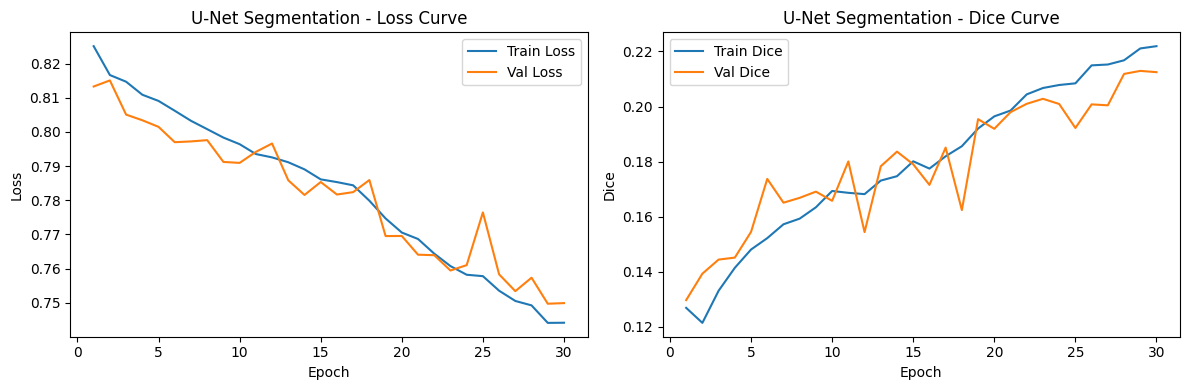

In [ ]:
# ============================================================
# 14. TRAIN U-NET, SAVE BEST, PLOT SEGMENTATION CURVES
# ============================================================

best_val_dice = -np.inf
seg_train_losses, seg_val_losses = [], []
seg_train_dices, seg_val_dices   = [], []

for epoch in range(1, NUM_EPOCHS_SEG + 1):
    # ---------- TRAIN ----------
    unet_model.train()
    tr_loss = tr_iou = tr_dice = 0.0
    n_tr    = 0

    for imgs, masks in tqdm(seg_train_loader,
                            desc=f"Seg Train Epoch {epoch}", leave=False):
        imgs  = imgs.to(device)
        masks = masks.to(device)

        seg_optimizer.zero_grad()
        logits = unet_model(imgs)
        loss   = seg_criterion(logits, masks)
        loss.backward()
        seg_optimizer.step()

        tr_loss += loss.item() * imgs.size(0)
        tr_iou  += iou_from_logits(logits, masks, thr=0.4)
        tr_dice += dice_from_logits(logits, masks, thr=0.4)
        n_tr    += 1

    tr_loss /= len(seg_train_loader.dataset)
    tr_iou  /= n_tr
    tr_dice /= n_tr

    # ---------- VALIDATION ----------
    unet_model.eval()
    val_loss = val_iou = val_dice = 0.0
    n_val    = 0

    with torch.no_grad():
        for imgs, masks in tqdm(seg_val_loader,
                                desc=f"Seg Val Epoch {epoch}", leave=False):
            imgs  = imgs.to(device)
            masks = masks.to(device)

            logits = unet_model(imgs)
            loss   = seg_criterion(logits, masks)

            val_loss += loss.item() * imgs.size(0)
            val_iou  += iou_from_logits(logits, masks, thr=0.4)
            val_dice += dice_from_logits(logits, masks, thr=0.4)
            n_val    += 1

    val_loss /= len(seg_val_loader.dataset)
    val_iou  /= n_val
    val_dice /= n_val

    seg_scheduler.step(val_loss)

    seg_train_losses.append(tr_loss)
    seg_val_losses.append(val_loss)
    seg_train_dices.append(tr_dice)
    seg_val_dices.append(val_dice)

    print(
        f"Seg Epoch {epoch}/{NUM_EPOCHS_SEG} | "
        f"Train Loss: {tr_loss:.4f}, IoU: {tr_iou:.4f}, Dice: {tr_dice:.4f} | "
        f"Val Loss: {val_loss:.4f}, IoU: {val_iou:.4f}, Dice: {val_dice:.4f}"
    )

    if val_dice > best_val_dice:
        best_val_dice = val_dice
        torch.save(unet_model.state_dict(), BEST_UNET_PATH)
        print(f"✅ Saved best U-Net to {BEST_UNET_PATH}")

print("Segmentation training complete. Best Val Dice:", best_val_dice)

# ---- Plot segmentation loss & Dice curves ----
seg_epochs = np.arange(1, len(seg_train_losses) + 1)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(seg_epochs, seg_train_losses, label="Train Loss")
plt.plot(seg_epochs, seg_val_losses,   label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("U-Net Segmentation - Loss Curve")
plt.legend()

plt.subplot(1,2,2)
plt.plot(seg_epochs, seg_train_dices, label="Train Dice")
plt.plot(seg_epochs, seg_val_dices,   label="Val Dice")
plt.xlabel("Epoch")
plt.ylabel("Dice")
plt.title("U-Net Segmentation - Dice Curve")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# 15. SEGMENTATION VISUALIZATION HELPERS + 5 RANDOM EXAMPLES
# ============================================================

# Inverse normalization for visualization
inv_mean = np.array([0.485, 0.456, 0.406])
inv_std  = np.array([0.229, 0.224, 0.225])

def denormalize_image(img_tensor):
    img = img_tensor.permute(1, 2, 0).cpu().numpy()
    img = img * inv_std + inv_mean
    img = np.clip(img, 0, 1)
    return img

# Helper to pick default model
def _get_default_model(model=None):
    if model is not None:
        return model
    if 'unet_model' in globals():
        return unet_model
    raise RuntimeError("No model passed and unet_model not found.")

@torch.no_grad()
def show_segmentation_hybrid(idx, thr=0.5, model=None):
    """
    Full hybrid visualization (best for report):
      1) Image
      2) Groundtruth Mask
      3) Predicted Binary Mask
      4) Probability Map
      5) Overlay (Prob on Image)
    Uses seg_val_dataset[idx].
    """
    model = _get_default_model(model)
    model.eval()

    img, mask = seg_val_dataset[idx]
    img_t = img.unsqueeze(0).to(device)

    logits = model(img_t)
    prob   = torch.sigmoid(logits)[0, 0].cpu().numpy()
    pred_bin = (prob > thr).astype(np.float32)

    img_np  = denormalize_image(img)
    gt_np   = mask[0].cpu().numpy()
    pred_np = pred_bin

    heatmap = cv2.applyColorMap(
        (prob * 255).astype(np.uint8),
        cv2.COLORMAP_JET
    )
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    overlay = 0.6 * img_np + 0.4 * (heatmap / 255.0)
    overlay = np.clip(overlay, 0, 1)

    plt.figure(figsize=(20, 4))

    plt.subplot(1, 5, 1)
    plt.title("Image")
    plt.imshow(img_np)
    plt.axis("off")

    plt.subplot(1, 5, 2)
    plt.title("Groundtruth Mask")
    plt.imshow(gt_np, cmap="gray")
    plt.axis("off")

    plt.subplot(1, 5, 3)
    plt.title(f"Predicted Mask (thr={thr})")
    plt.imshow(pred_np, cmap="gray")
    plt.axis("off")

    plt.subplot(1, 5, 4)
    plt.title("Probability Map")
    plt.imshow(prob, cmap="jet")
    plt.axis("off")

    plt.subplot(1, 5, 5)
    plt.title("Overlay")
    plt.imshow(overlay)
    plt.axis("off")

    plt.tight_layout()
    plt.show()

# Show 5 random validation examples
indices = np.random.choice(len(seg_val_dataset),
                           size=min(5, len(seg_val_dataset)),
                           replace=False)
for idx in indices:
    show_segmentation_hybrid(idx, thr=0.35)

Output hidden; open in https://colab.research.google.com to view.